## Customer Churn Prediction

In [58]:
# Importing libraries
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, roc_curve)


## Loading data and EDA

In [27]:
#Import the datasets from github
#url = 'https://raw.githubusercontent.com/Levice085/Customer_churn_prediction/refs/heads/main/datasets/Telco-Customer-Churn.csv'
#response = requests.get(url)

#with open("churn.csv", "wb") as f:
    #f.write(response.content)
df = pd.read_csv("churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
print(f"The shape of the dataset is: {(df.shape)}")
print(f"Total columns: {len(df.columns)}")
print(f"The column names are: {df.columns.tolist()}")

The shape of the dataset is: (7043, 21)
Total columns: 21
The column names are: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [29]:
#Viewing the columns data types
print(f"The column data types are: {df.dtypes}")

The column data types are: customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [30]:
#Checking for missing data
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [31]:
# Checking for duplicates
print(df.duplicated().sum())

0


Churn
No     5174
Yes    1869
Name: count, dtype: int64
 The churn rate is: 26.54%


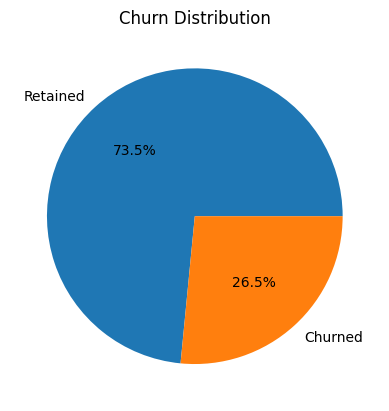

In [32]:
#Finding the churn rate
print(df["Churn"].value_counts())
print(f" The churn rate is: {df["Churn"].eq("Yes").mean()*100:.2f}%")

#Visualizing the churn rate
df["Churn"].value_counts().plot(
    kind = 'pie',
    title = "Churn Distribution",
    autopct = '%1.1f%%',
    labels = ["Retained", "Churned"]
)

plt.ylabel('')
plt.show()

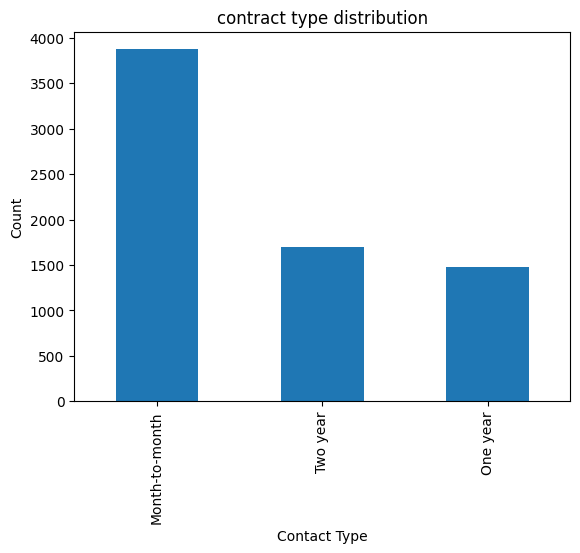

In [33]:
#Showing the contract type distribution
df["Contract"].value_counts().plot(
    kind = 'bar',
    title = 'contract type distribution'
)
plt.xlabel("Contact Type")
plt.ylabel("Count")
plt.show()

Text(0.5, 0, 'Monthly charges')

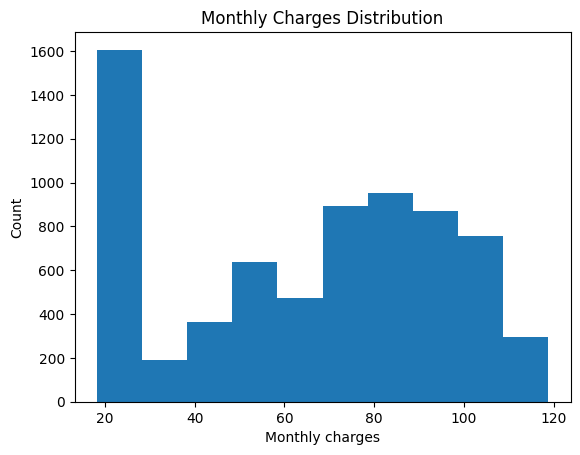

In [34]:
#Monthly charges distribution
df["MonthlyCharges"].plot(
    kind = 'hist',
    title = 'Monthly Charges Distribution'
)
plt.ylabel('Count')
plt.xlabel('Monthly charges')

Text(0.5, 0, 'Tenure')

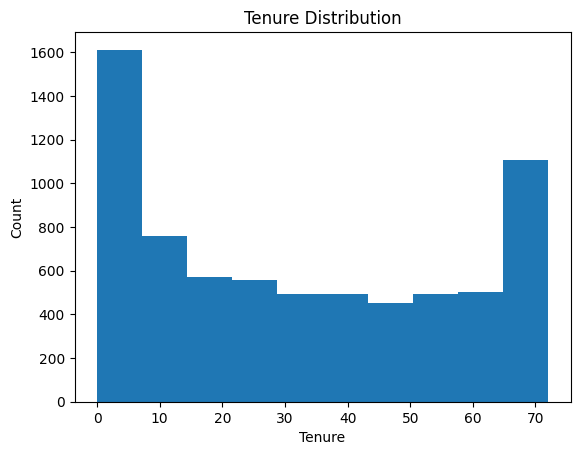

In [35]:
# Tenure distribution
df["tenure"].plot(
    kind = 'hist',
    title = 'Tenure Distribution'
)
plt.ylabel('Count')
plt.xlabel('Tenure')

Text(0.5, 0, 'Count')

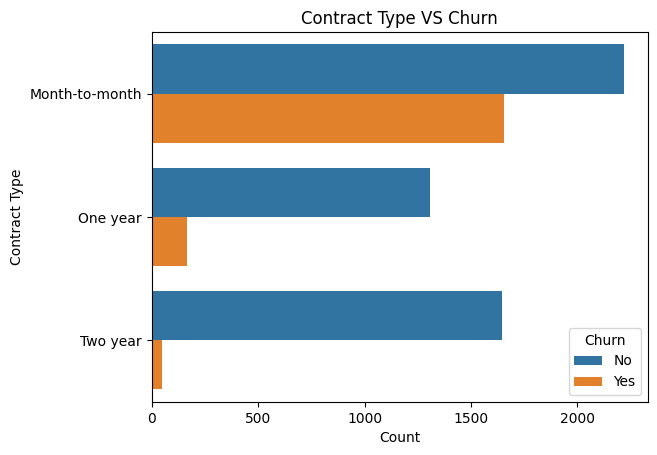

In [36]:
#Contact type vs churn
sns.countplot(y = 'Contract', hue = 'Churn', data = df)
plt.title("Contract Type VS Churn")
plt.ylabel("Contract Type")
plt.xlabel("Count")

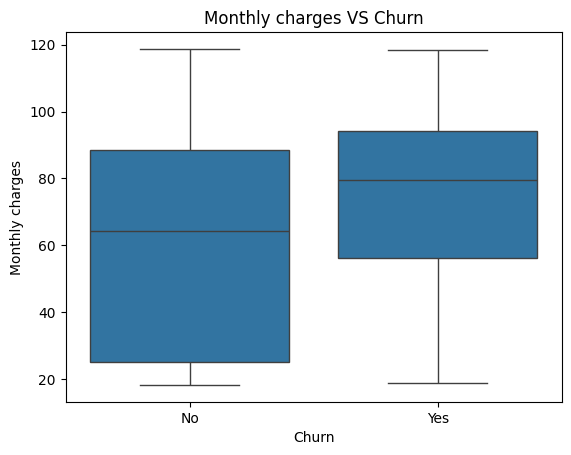

In [37]:
# Monthly charges VS churn
sns.boxplot(x = 'Churn', y = 'MonthlyCharges', data = df)
plt.title("Monthly charges VS Churn")
plt.xlabel('Churn')
plt.ylabel('Monthly charges')
plt.show()

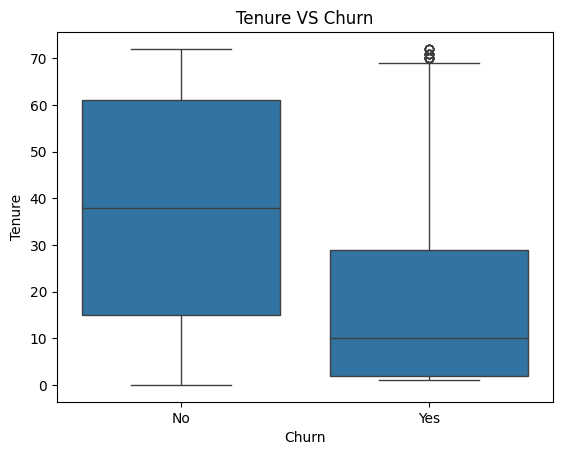

In [38]:
# Tenure VS churn
sns.boxplot(x = 'Churn', y = 'tenure', data = df)
plt.title("Tenure VS Churn")
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

From the findings we can conclude that:

1. The customer is likely to churn when the monthly charges are high
2. The shorter the customer's tenure the most likely they will churn
3. Highest churn rates are recorded with month-month contract type

In [39]:
#Summary of binary columns
df[["SeniorCitizen","tenure","MonthlyCharges"]].describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


<Axes: >

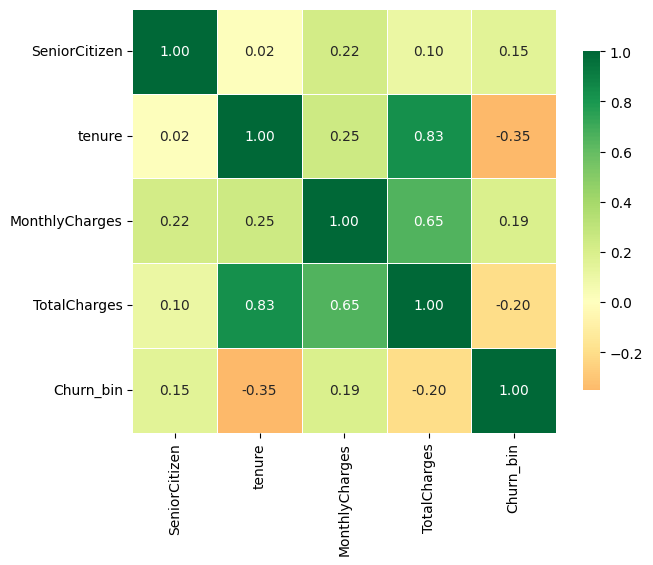

In [40]:
#Generate a correlation map
df_temp = df.copy()
df_temp["TotalCharges"] = pd.to_numeric(df_temp["TotalCharges"], errors = 'coerce')

df_temp["Churn_bin"] = (df_temp["Churn"] == "Yes").astype(int)
num_cols = ["SeniorCitizen","tenure","MonthlyCharges","TotalCharges","Churn_bin"]

#Correlation
corr = df_temp[num_cols].corr()

fig, ax = plt.subplots(figsize = (7, 5.5))
sns.heatmap(corr, annot = True, cmap = 'RdYlGn', fmt = '.2f',ax=ax, center = 0, 
                linewidths = 0.5,square = True,cbar_kws = {'shrink':0.8})



## Data processing and feature engineering 

In [41]:
#Showing the relationship between churn and monthly charges
print("The rlship btwn churn and monthly charges:\n ",df.groupby("Churn")['MonthlyCharges'].mean())

#Showing the relationship between churn,gender and monthly charges
print("\nThe rlship btwn churn,age and monthly charges:\n ", df.groupby(["Churn","gender"])['MonthlyCharges'].mean())

#Showing the relationship between churn and tenure
print("The rlship btwn churn and tenure:\n ",df.groupby("Churn")['tenure'].mean())

The rlship btwn churn and monthly charges:
  Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

The rlship btwn churn,age and monthly charges:
  Churn  gender
No     Female    61.664908
       Male      60.876914
Yes    Female    74.812087
       Male      74.066989
Name: MonthlyCharges, dtype: float64
The rlship btwn churn and tenure:
  Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


In [42]:
# Convert total charges to numeric
df_model = df.copy()
df_model["TotalCharges"] = pd.to_numeric(df_model["TotalCharges"], errors = 'coerce')
print(f"Number of Nan's after converting to numeric: {df_model["TotalCharges"].isnull().sum()}")

# Replace the Nan's with the mean of totalcharges
df_model["TotalCharges"] = df_model["TotalCharges"].fillna(df_model["TotalCharges"].median())

# Drop the non predictive identifier
df_model.drop("customerID", axis = 1, inplace = True)


Number of Nan's after converting to numeric: 11


In [43]:
# Encode the target variable and label encode the remaining object columns
df["Churn"] = df["Churn"].apply(lambda x:1 if x == 'Yes' else 0)
#print(df.dtypes)

le = LabelEncoder()
cat_columns = df_model.select_dtypes(include= 'object').columns.tolist()
print(cat_columns)

for col in cat_columns:
    df_model[col] = le.fit_transform(df_model[col])
print("\n Encording Complete!")

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

 Encording Complete!


## Model training

In [44]:
#Splitting data for training and testing
X = df_model.drop("Churn", axis = 1)
y = df_model["Churn"]

#Simple Imputer
imputer = SimpleImputer(strategy= "median")
imputer_cols = X.columns.tolist()
for col in imputer_cols:
    X[col] = imputer.fit_transform(pd.DataFrame(X[col]))
print("Simple imputer with median complete!")

#Standard scaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns= X.columns)
print("Standard scaler complete!")


#Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y)

print(f"\nThe train size: {X_train.shape} | The test size:{X_test.shape}")

Simple imputer with median complete!
Standard scaler complete!

The train size: (5634, 19) | The test size:(1409, 19)


In [47]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=100, random_state=42),
    "Random Forest" : RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting" : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,max_depth=4,random_state=42)

}

results = {}
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
            'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
            'accuracy':  accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall':    recall_score(y_test, y_pred),
            'f1':        f1_score(y_test, y_pred),
            'roc_auc':   roc_auc_score(y_test, y_prob)
        }
    print(f"{name:30s}  Acc={results[name]['accuracy']:.4f}  "
          f"F1={results[name]['f1']:.4f}  AUC={results[name]['roc_auc']:.4f}")
    


c:\Users\levie\miniconda3\envs\geo\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression             Acc=0.7885  F1=0.5826  AUC=0.8368
Random Forest                   Acc=0.7892  F1=0.5520  AUC=0.8256
Gradient Boosting               Acc=0.7999  F1=0.5753  AUC=0.8413


In [48]:
# Model comparison table
metrics_df = pd.DataFrame({
    name: {k: round(v, 4) for k, v in res.items() if isinstance(v, float)}
    for name, res in results.items()
}).T
metrics_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
display(metrics_df)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.7885,0.6118,0.5561,0.5826,0.8368
Random Forest,0.7892,0.6332,0.4893,0.5520,0.8256
Gradient Boosting,0.7999,0.6586,0.5107,0.5753,0.8413


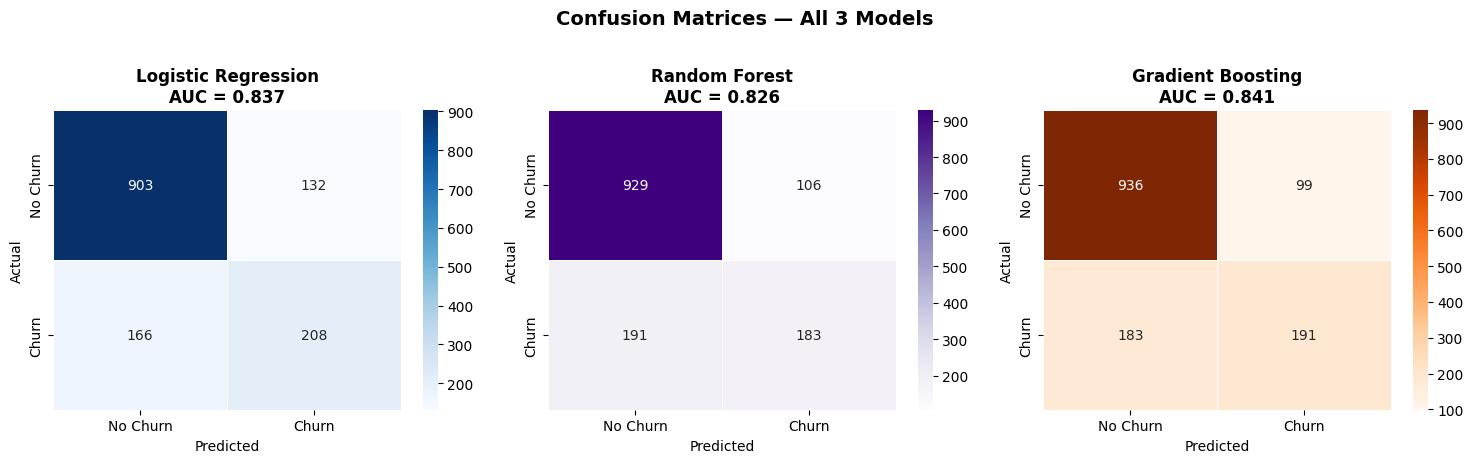

In [50]:
# Confusion matrices — side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, res), cmap in zip(axes, results.items(), ['Blues','Purples','Oranges']):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, linewidths=0.5,
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    ax.set_title(f'{name}\nAUC = {res["roc_auc"]:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — All 3 Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("charts/confusion_matrices.png", bbox_inches='tight')
plt.show()

In [57]:
# [ADVANCED] Hyperparameter tuning with GridSearchCV on Gradient Boosting
param_grid = {
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators':  [100, 200]
}
gb_base = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(gb_base, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)
best_gb = grid_search.best_estimator_

print(f"Best params : {grid_search.best_params_}")
print(f"Best CV AUC : {grid_search.best_score_:.4f}")
test_auc = roc_auc_score(y_test, best_gb.predict_proba(X_test)[:,1])
print(f"Test AUC (tuned GB): {test_auc:.4f}")

Best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV AUC : 0.8476
Test AUC (tuned GB): 0.8451


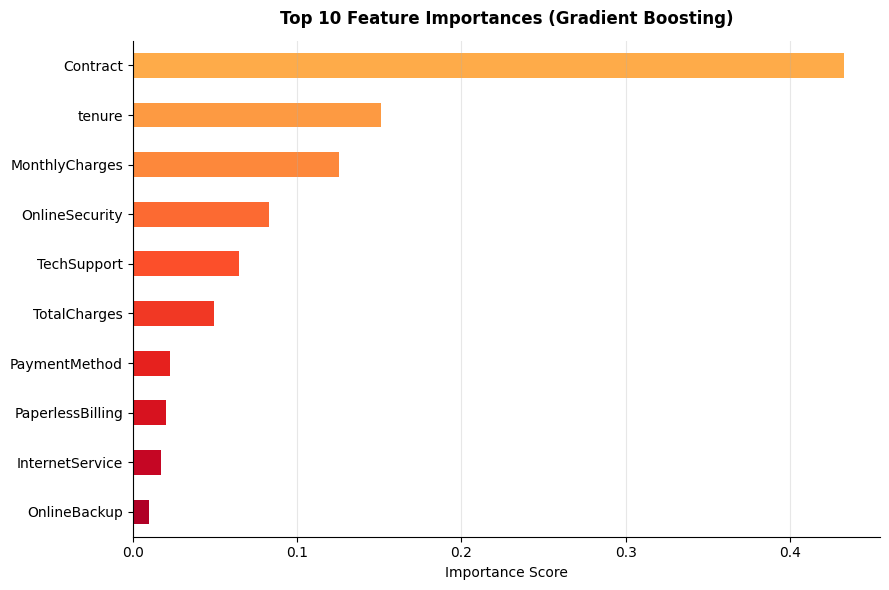

In [59]:
# Feature Importance 
feat_imp = pd.Series(best_gb.feature_importances_, index=X.columns).nlargest(10)
fig, ax = plt.subplots(figsize=(9, 6))
colors_grad = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(feat_imp)))[::-1]
feat_imp.sort_values().plot(kind='barh', ax=ax, color=colors_grad, edgecolor='none')
ax.set_title('Top 10 Feature Importances (Gradient Boosting)', fontweight='bold', pad=12)
ax.set_xlabel('Importance Score'); ax.grid(axis='x', alpha=0.3)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
plt.tight_layout(); 
plt.savefig("charts/chart1_feature_importance.png", bbox_inches='tight'); 
plt.show()